## Preliminaries

### Import statements

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

### Global values

In [2]:
data_dir = "data"

### Load tokens

In [3]:
token_file = os.path.join(data_dir, "tokens.tsv")
tokens = pd.read_csv(token_file, delimiter="\t", dtype=str)

### Collapse elided with unelided lemmas

In [4]:
tokens.loc[tokens["lemma"]=="δʼ", "lemma"] = "δέ"
tokens.loc[tokens["lemma"]=="τʼ", "lemma"] = "τε"
tokens.loc[tokens["lemma"]=="ἀλλʼ", "lemma"] = "ἀλλά"
tokens.loc[tokens["lemma"]=="ἄρʼ", "lemma"] = "ἄρα"
tokens.loc[tokens["lemma"]=="ἐπʼ", "lemma"] = "ἐπί"
tokens.loc[tokens["lemma"]=="οὐδʼ", "lemma"] = "οὐδέ"

### Select most frequent lemmas

In [5]:
# corpus-wide count for all non-punctuation lemmas, from most frequent to least
corpus_lemma_count = tokens.loc[~(tokens["pos"]=="PUNCT"), "lemma"].value_counts()

# a list of the top lemmas
top_lemmas = corpus_lemma_count.head(100).index

# show results
display(corpus_lemma_count.loc[top_lemmas])

lemma
δέ       21335
καί      13599
ὁ         9589
τε        5291
ἐγώ       3783
         ...  
λαός       494
ἄρης       493
ὅσος       492
οὗτος      488
ὕδωρ       482
Name: count, Length: 100, dtype: int64

### Experiment class

Define a bare-bones class to bundle experiment data

In [11]:
class Experiment(object):
    '''A bundle of input and output data related to one trial'''

    def __init__(self, name, tokens, feature_set):
        self.name = name
        self.tokens = tokens
        self.feature_set = feature_set

    def __repr__(self):
        return(f"<Experiment: {self.name}>")

## Cluster based on authorship and speech/narative

In this experiment, we try to achieve a two-way separation on two categorical groupings:
 - authorship (6 classes, assuming Iliad and Odyssey are different)
 - speech versus narrative (3 classes, leaving Odysseus' apologue as "other" for now)

### Instantiate an experiment

In [12]:
ex_base = Experiment(
    name = "Speech/nar, by author, randomized",
    tokens = tokens,
    feature_set = top_lemmas,
)

### Generate samples

In [18]:
# Narratological groups
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

# default group is "other"
ex_base.nara_group_ids = pd.Series("oth", index=tokens.index)
ex_base.nara_group_ids[nr_mask] = "nar"
ex_base.nara_group_ids[sp_mask] = "spk"

# Authorship groups
ex_base.auth_group_ids = tokens["work"].str.slice(0,4)

# Combined two-factor group
ex_base.group_ids = ex_base.auth_group_ids + "-" + ex_base.nara_group_ids

# Sample labels
sample_size = 1000
ex_base.sample_ids = pd.Series(index=tokens.index)
for group in ex_base.group_ids.unique():
    n_toks = sum(ex_base.group_ids==group)
    ex_base.sample_ids.loc[ex_base.group_ids==group] = np.random.permutation(n_toks) // sample_size
ex_base.sample_ids = ex_base.group_ids + "-" + ex_base.sample_ids.map(lambda f: f"{int(f):03d}")

# Calculate sample sizes
ex_base.tokens_per_sample = ex_base.tokens.groupby(ex_base.sample_ids).size()

# Generate feature tallies
ex_base.samples = (pd.get_dummies(ex_base.tokens["lemma"])[ex_base.feature_set]
    .groupby(ex_base.sample_ids)
    .agg("sum")
)

# normalize as freq / 1000 words
ex_base.samples = ex_base.samples.div(ex_base.tokens_per_sample, axis=0) * 1000

### Perform PCA

This part should be the same for all experiments, so I'm going to write a function

In [19]:
def run_pca(ex):
    '''Run dimensionality reduction on an experimental dataset
        - assumes experiment has `samples` attribute
        - populates `scaled`, `pca_model`, `pca`
    '''
    
    # scaling
    ex.scaled = pd.DataFrame(
        data = StandardScaler().fit_transform(ex.samples),
        columns = ex.samples.columns,
        index = ex.samples.index,
    )
    
    # pca
    ex.pca_model = PCA(n_components=3)
    ex.pca = pd.DataFrame(
        data = ex.pca_model.fit_transform(ex.scaled), 
        columns = ["PC1", "PC2", "PC3"],
        index = ex.samples.index,
    )

In [20]:
run_pca(ex_base)
display(ex_base.pca)

,PC1,PC2,PC3
Argo-nar-000,-1.504541,1.733915,-0.577773
Argo-nar-001,-1.573277,2.085453,-0.333533
Argo-nar-002,-0.303747,3.539776,0.641484
Argo-nar-003,-0.598681,3.014080,0.648733
Argo-nar-004,0.046438,2.930798,0.516409
...,...,...,...
Sack-nar-001,-1.699007,1.363477,-1.100118
Sack-nar-002,-2.332940,1.907409,0.327108
Sack-nar-003,-1.950881,1.394322,-1.251320
Sack-spk-000,0.340106,-1.989424,-1.189884


### Plot

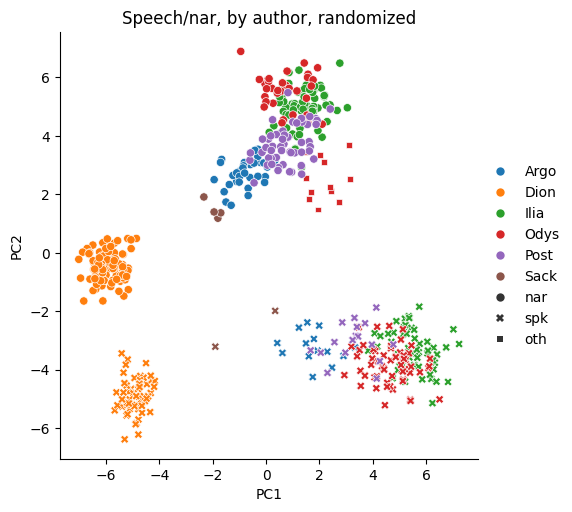

In [25]:
# plot
auth_labels = ex_base.auth_group_ids.groupby(ex_base.sample_ids).agg("first").values
nara_labels = ex_base.nara_group_ids.groupby(ex_base.sample_ids).agg("first").values

g = ex_base.fig = sns.relplot(data=ex_base.pca,
    x = "PC1",
    y = "PC2",
    hue = auth_labels,
    style = nara_labels,
)
g.set(title = ex_base.name)
ex_base.fig = g.figure

### Fit linear model

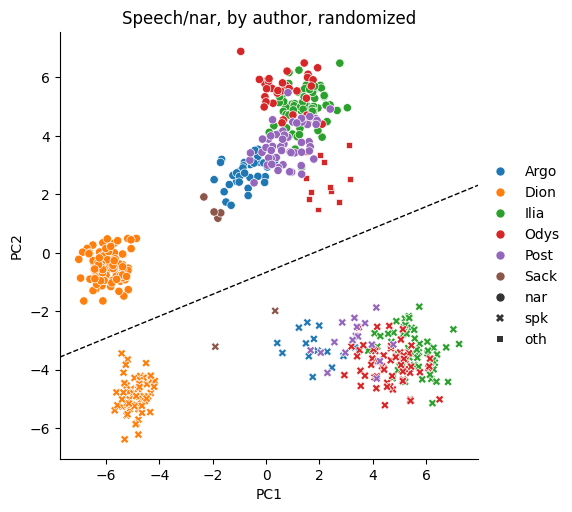

In [34]:
# fit on nar/spk only
mask = nara_labels != "oth"
X = ex_base.pca.loc[mask, ["PC1", "PC2"]].values
y = (nara_labels[mask] == "spk").astype(int)

ex_base.clf = LogisticRegression()
ex_base.clf.fit(X, y)

# the decision boundary normal vector is clf.coef_
# project all points onto that axis
all_X = ex_base.pca[["PC1", "PC2"]].values
proj = all_X @ ex_base.clf.coef_.T + ex_base.clf.intercept_
ex_base.speech_score = pd.Series(proj.flatten(), index=ex_base.pca.index)

# get the axis for the previous plot
ax = ex_base.fig.get_axes()[0]

# get the axis limits from the plot
xlim = ax.get_xlim()

# solve for y at each x endpoint: coef[0]*x + coef[1]*y + intercept = 0
#   => y = -(coef[0]*x + intercept) / coef[1]
w = ex_base.clf.coef_[0]
b = ex_base.clf.intercept_[0]
xs = np.array(xlim)
ys = -(w[0] * xs + b) / w[1]

ax.plot(xs, ys, "k--", linewidth=1)
ax.set_xlim(xlim)  # restore limits so the line doesn't expand the plot

display(ex_base.fig)

## Calculate rolling samples

In [38]:
window_size = 1000

ex_roll = Experiment(
    name = f"Rolling window {window_size}",
    tokens = tokens,
    feature_set = top_lemmas,
)

# rolling samples
ex_roll.samples = (
    pd.get_dummies(ex_roll.tokens["lemma"])[ex_roll.feature_set]
    .rolling(
        window = window_size, 
        center = True,
        min_periods = int(window_size * 0.7))
    .agg("sum")
    .fillna(0)
    .astype(int)
)

# calculate size of samples for normalization
ex_roll.tokens_per_sample = (ex_roll.tokens["lemma"]
    .rolling(
        window = window_size,
        center = True,
        min_periods = int(window_size * 0.7)
    )
    .agg("count")
    .fillna(0)
    .astype(int)
)

# get frequencies
ex_roll.samples = ex_roll.samples.div(ex_roll.tokens_per_sample, axis=0) * 1000

# scaling
ex_roll.scaled = pd.DataFrame(
    data = StandardScaler().fit_transform(ex_roll.samples),
    columns = ex_roll.samples.columns,
    index = ex_roll.samples.index,
)

# pca
ex_roll.pca = pd.DataFrame(
    data = ex_base.pca_model.transform(ex_roll.scaled.dropna()),
    columns = ["PC1", "PC2", "PC3"],
    index = ex_roll.scaled.dropna().index,
)

# calculate speechiness score
X = ex_roll.pca[["PC1", "PC2"]].values
proj = X @ ex_base.clf.coef_.T + ex_base.clf.intercept_
ex_roll.speech_score = pd.DataFrame(dict(
    work = tokens.loc[ex_roll.pca.index, "work"],
    pref = tokens.loc[ex_roll.pca.index, "pref"],
    line = tokens.loc[ex_roll.pca.index, "line"],
    score = proj.flatten(), 
    ),
    index = ex_roll.pca.index)
display(ex_roll.speech_score)

,work,pref,line,score
200,Iliad,1,26,5.051016
201,Iliad,1,26,5.035234
202,Iliad,1,27,5.019497
203,Iliad,1,27,5.135209
204,Iliad,1,27,5.047776
...,...,...,...,...
496223,Dionysiaca,48,948,-0.878159
496224,Dionysiaca,48,948,-0.870856
496225,Dionysiaca,48,948,-0.863532
496226,Dionysiaca,48,949,-0.856188


### Plot speech score by verse line

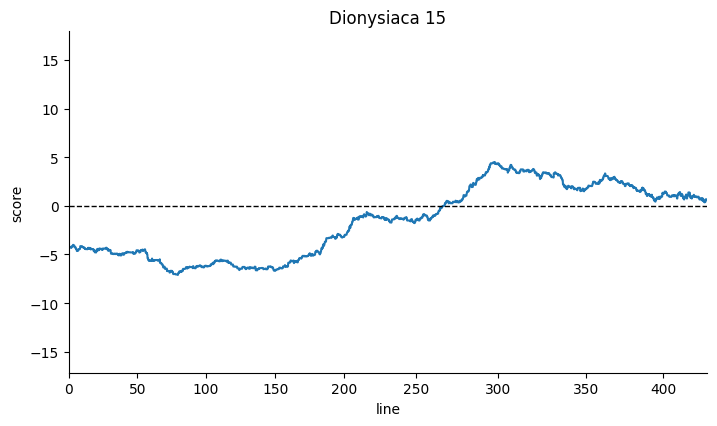

In [40]:
work = "Dionysiaca"
pref = "15"
mask = (ex_roll.speech_score["work"] == work) & (ex_roll.speech_score["pref"] == pref)

g = sns.relplot(
    x = ex_roll.speech_score[mask].index,
    y = ex_roll.speech_score[mask].score,
    kind = "line",
)
g.set(
    title = work + " " + pref,
    xlabel = "line",
)
g.figure.set_size_inches(8, 4)

# set x-tics
xmin = ex_roll.speech_score[mask].index.min()
xmax = ex_roll.speech_score[mask].index.max()
ymin = ex_roll.speech_score["score"].min()
ymax = ex_roll.speech_score["score"].max()

x_ticks = []
x_tick_labels = []
for idx in ex_roll.speech_score[mask].index:
    ln = ex_roll.speech_score.loc[idx, "line"]
    if int(ln) % 50 == 0:
        if ln not in x_tick_labels:
            x_ticks.append(idx)
            x_tick_labels.append(ln)
g.ax.plot([xmin,xmax], [0,0], "k--", lw=1)
g.set(
    xticks = x_ticks,
    xticklabels = x_tick_labels,
    xlim = (xmin, xmax),
    ylim = (ymin, ymax),
)